In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def normalize_text(s):
    return re.sub(r'[^a-zA-Z0-9 ]', '', s.lower().strip())

def join_tokens(row):
    return ' '.join([str(x).strip() for x in row if pd.notna(x)])

def get_best_match(label, vocab_list):
    label_norm = normalize_text(label)
    vocab_norm = [normalize_text(v) for v in vocab_list]

    # Tier 1: Close string match
    close = get_close_matches(label_norm, vocab_norm, n=1, cutoff=0.85)
    if close:
        return close[0], 'best'

    # Tier 2: Jaccard token match
    label_tokens = set(label_norm.split())
    best_score = 0
    best_match = None
    for v in vocab_norm:
        v_tokens = set(v.split())
        score = len(label_tokens & v_tokens) / len(label_tokens | v_tokens)
        if score > best_score:
            best_score = score
            best_match = v
    if best_score > 0.3:
        return best_match, 'ok'

    # Tier 3: TF-IDF fallback
    tfidf = TfidfVectorizer().fit([label_norm] + vocab_norm)
    sims = cosine_similarity(tfidf.transform([label_norm]), tfidf.transform(vocab_norm)).flatten()
    idx = sims.argmax()
    return vocab_norm[idx], 'fallback'

def match_finediving_to_vocab(df_finediving, df_vocab, vocab_col_range=('0', '3'), finediving_col_range=('0', None)):
    # Combine tokens into labels
    df_finediving = df_finediving.copy()
    df_vocab = df_vocab.copy()

    if finediving_col_range[1] is not None:
        df_finediving['label'] = df_finediving.loc[:, finediving_col_range[0]:finediving_col_range[1]].apply(join_tokens, axis=1)
    else:
        df_finediving['label'] = df_finediving.loc[:, finediving_col_range[0]:].apply(join_tokens, axis=1)

    df_vocab['label'] = df_vocab.loc[:, vocab_col_range[0]:vocab_col_range[1]].apply(join_tokens, axis=1)

    # Normalize and match
    vocab_list = df_vocab['label'].tolist()
    vocab_normalized = [normalize_text(label) for label in vocab_list]
    label_to_index = {label: idx for idx, label in zip(vocab_normalized, df_vocab.index)}

    matched_classes = []
    match_types = []

    for label in df_finediving['label']:
        match, mtype = get_best_match(label, vocab_list)
        matched_classes.append(match)
        match_types.append(mtype)

    df_finediving['matched_class'] = matched_classes
    df_finediving['match_type'] = match_types

    # Compute matched index
    df_finediving['matched_vocab_index'] = df_finediving['matched_class'].apply(
        lambda x: label_to_index.get(normalize_text(x), -1)
    )

    # Class-to-class summary
    class_to_vocab_matches = df_finediving.groupby('label')['matched_class'].agg(['count', lambda x: list(x.unique())])
    class_to_vocab_matches.columns = ['finediving_count', 'matched_diving48_classes']
    match_types_summary = df_finediving.groupby('label')['match_type'].value_counts().unstack(fill_value=0)
    final_summary = class_to_vocab_matches.merge(match_types_summary, left_index=True, right_index=True)
    final_summary = final_summary.sort_values(by='finediving_count', ascending=False)

    return df_finediving, final_summary

In [55]:
df_finediving = pd.read_csv("/Users/mrinalraj/Downloads/WebDownload/Preprocess/FineDivingClassLikeDiving38.csv")
df_vocab = pd.read_csv("df_vocab.csv")

df_result, class_summary = match_finediving_to_vocab(df_finediving, df_vocab)

In [56]:
df_result

,Unnamed: 0,id,code,0,1,2,3,4,5,label,matched_class,match_type,matched_vocab_index
0,0,1,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
1,1,2,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
2,2,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
3,3,4,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
4,4,5,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2752,2995,2996,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
2753,2996,2997,109c,Forward,45som,TUCK,NaN,NaN,NaN,Forward 45som TUCK,forward 45som notwis tuck,ok,-1
2754,2997,2998,5255b,Back,25Twis,25som,PIKE,NaN,NaN,Back 25Twis 25som PIKE,back 25som 25twis pike,ok,-1
2755,2998,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1


In [57]:
class_summary

,finediving_count,matched_diving48_classes,matched_vocab_indices,most_common_index,best,ok
label,,,,,,
Inward 35som TUCK,345,[inward 35som notwis tuck],[-1],-1,0,345
Forward 35som PIKE,322,[forward 35som notwis pike],[-1],-1,0,322
Reverse 35som TUCK,231,[reverse 35som notwis tuck],[-1],-1,0,231
Back 25som PIKE,205,[back 25som 15twis pike],[-1],-1,0,205
Back 15Twis 25som PIKE,203,[back 25som 15twis pike],[-1],-1,0,203
Back 35som TUCK,159,[back 35som notwis tuck],[-1],-1,0,159
Forward 45som TUCK,158,[forward 45som notwis tuck],[-1],-1,0,158
Inward 25som PIKE,132,[inward 25som notwis pike],[-1],-1,0,132
Forward 25som PIKE 2Twis,110,[forward 25som 2twis pike],[-1],-1,0,110


In [68]:
vocabMergedAction = df_vocab[['0', '1', '2', '3']].astype(str).agg(' '.join, axis=1).str.lower().str.strip().reset_index()

In [69]:
vocabMergedAction

,index,0
0,0,back 15som 05twis free
1,1,back 15som 15twis free
2,2,back 15som 25twis free
3,3,back 15som notwis pike
4,4,back 15som notwis tuck
5,5,back 25som 15twis pike
6,6,back 25som 25twis pike
7,7,back 25som notwis pike
8,8,back 25som notwis tuck
9,9,back 2som 15twis free


In [72]:
vocabMergedAction[0]

0        back 15som 05twis free
1        back 15som 15twis free
2        back 15som 25twis free
3        back 15som notwis pike
4        back 15som notwis tuck
5        back 25som 15twis pike
6        back 25som 25twis pike
7        back 25som notwis pike
8        back 25som notwis tuck
9         back 2som 15twis free
10        back 2som 25twis free
11       back 35som notwis pike
12       back 35som notwis tuck
13        back 3som notwis pike
14        back 3som notwis tuck
15        back dive notwis pike
16        back dive notwis tuck
17     forward 15som 1twis free
18     forward 15som 2twis free
19    forward 15som notwis pike
20     forward 1som notwis pike
21     forward 25som 1twis pike
22     forward 25som 2twis pike
23     forward 25som 3twis pike
24    forward 25som notwis pike
25    forward 25som notwis tuck
26    forward 35som notwis pike
27    forward 35som notwis tuck
28    forward 45som notwis tuck
29     forward dive notwis pike
30      forward dive notwis str
31     i

In [75]:
class_summary['matched_diving48_classes_str'] = class_summary['matched_diving48_classes'].apply(lambda x: x[0].lower().strip() if isinstance(x, list) and len(x) > 0 else '')
class_summary

,finediving_count,matched_diving48_classes,matched_vocab_indices,most_common_index,best,ok,matched_diving48_classes_str
label,,,,,,,
Inward 35som TUCK,345,[inward 35som notwis tuck],[-1],-1,0,345,inward 35som notwis tuck
Forward 35som PIKE,322,[forward 35som notwis pike],[-1],-1,0,322,forward 35som notwis pike
Reverse 35som TUCK,231,[reverse 35som notwis tuck],[-1],-1,0,231,reverse 35som notwis tuck
Back 25som PIKE,205,[back 25som 15twis pike],[-1],-1,0,205,back 25som 15twis pike
Back 15Twis 25som PIKE,203,[back 25som 15twis pike],[-1],-1,0,203,back 25som 15twis pike
Back 35som TUCK,159,[back 35som notwis tuck],[-1],-1,0,159,back 35som notwis tuck
Forward 45som TUCK,158,[forward 45som notwis tuck],[-1],-1,0,158,forward 45som notwis tuck
Inward 25som PIKE,132,[inward 25som notwis pike],[-1],-1,0,132,inward 25som notwis pike
Forward 25som PIKE 2Twis,110,[forward 25som 2twis pike],[-1],-1,0,110,forward 25som 2twis pike


In [83]:

merged = class_summary.merge(vocabMergedAction, left_on='matched_diving48_classes_str', right_on=0, how='left')

print(merged.head())

                    label  finediving_count     matched_diving48_classes  \
0       Inward 35som TUCK               345   [inward 35som notwis tuck]   
1      Forward 35som PIKE               322  [forward 35som notwis pike]   
2      Reverse 35som TUCK               231  [reverse 35som notwis tuck]   
3         Back 25som PIKE               205     [back 25som 15twis pike]   
4  Back 15Twis 25som PIKE               203     [back 25som 15twis pike]   

  matched_vocab_indices  most_common_index  best   ok  \
0                  [-1]                 -1     0  345   
1                  [-1]                 -1     0  322   
2                  [-1]                 -1     0  231   
3                  [-1]                 -1     0  205   
4                  [-1]                 -1     0  203   

  matched_diving48_classes_str  index                          0  
0     inward 35som notwis tuck     35   inward 35som notwis tuck  
1    forward 35som notwis pike     26  forward 35som notwis pike  

In [84]:
merged.head()

,label,finediving_count,matched_diving48_classes,matched_vocab_indices,most_common_index,best,ok,matched_diving48_classes_str,index,0
0,Inward 35som TUCK,345,[inward 35som notwis tuck],[-1],-1,0,345,inward 35som notwis tuck,35,inward 35som notwis tuck
1,Forward 35som PIKE,322,[forward 35som notwis pike],[-1],-1,0,322,forward 35som notwis pike,26,forward 35som notwis pike
2,Reverse 35som TUCK,231,[reverse 35som notwis tuck],[-1],-1,0,231,reverse 35som notwis tuck,45,reverse 35som notwis tuck
3,Back 25som PIKE,205,[back 25som 15twis pike],[-1],-1,0,205,back 25som 15twis pike,5,back 25som 15twis pike
4,Back 15Twis 25som PIKE,203,[back 25som 15twis pike],[-1],-1,0,203,back 25som 15twis pike,5,back 25som 15twis pike


In [87]:
merged_final = merged.drop(columns=["best", "most_common_index", "ok", 0, "matched_vocab_indices", "matched_diving48_classes"])

In [88]:
merged_final.to_csv("CoverstionOfFineDivingToDiving48.csv")

In [89]:
merged_final

,label,finediving_count,matched_diving48_classes_str,index
0,Inward 35som TUCK,345,inward 35som notwis tuck,35
1,Forward 35som PIKE,322,forward 35som notwis pike,26
2,Reverse 35som TUCK,231,reverse 35som notwis tuck,45
3,Back 25som PIKE,205,back 25som 15twis pike,5
4,Back 15Twis 25som PIKE,203,back 25som 15twis pike,5
5,Back 35som TUCK,159,back 35som notwis tuck,12
6,Forward 45som TUCK,158,forward 45som notwis tuck,28
7,Inward 25som PIKE,132,inward 25som notwis pike,33
8,Forward 25som PIKE 2Twis,110,forward 25som 2twis pike,22
9,Forward 25som PIKE 1Twis,94,forward 25som 1twis pike,21


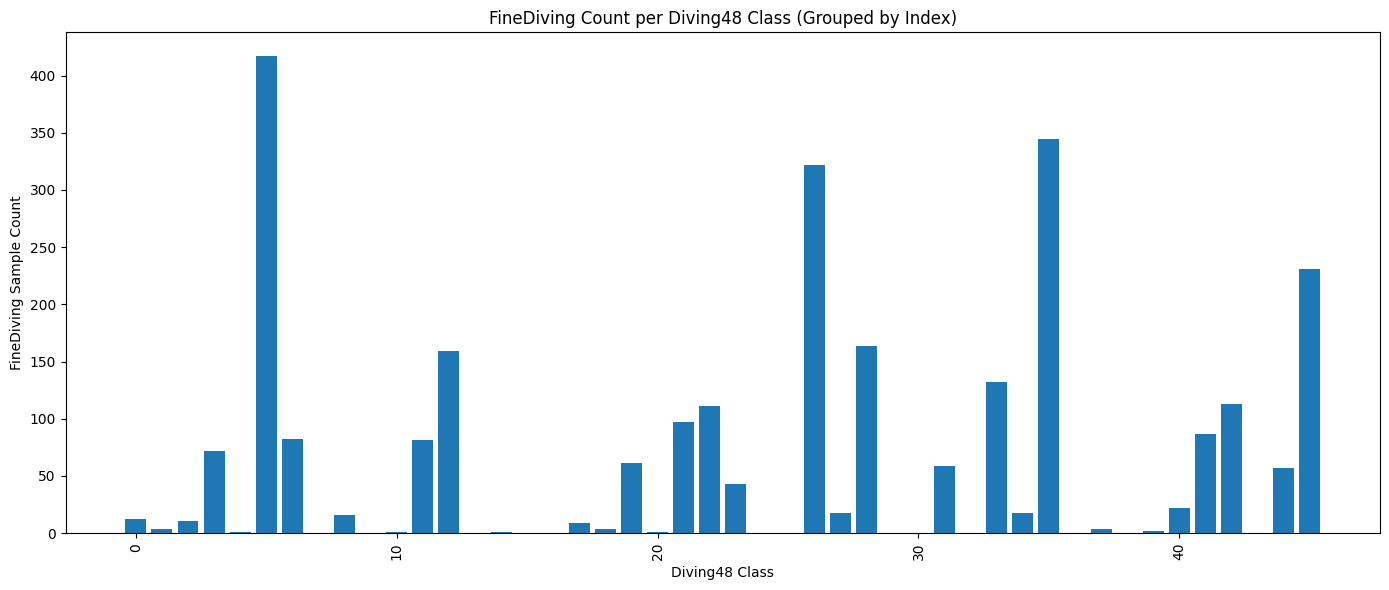

    index  finediving_count matched_diving48_classes_str
5       5               417       back 25som 15twis pike
25     35               345     inward 35som notwis tuck
19     26               322    forward 35som notwis pike
32     45               231    reverse 35som notwis tuck
21     28               164    forward 45som notwis tuck


In [104]:
import matplotlib.pyplot as plt

grouped_df = merged_final.groupby('index')['finediving_count'].sum().reset_index()

# 2. Merge one class name per index (we'll just use the first occurrence)
class_names = merged_final[['index', 'matched_diving48_classes_str']].drop_duplicates(subset='index')
summary_df = grouped_df.merge(class_names, on='index', how='left')

# 3. Sort by count descending
summary_df.sort_values(by='finediving_count', ascending=False, inplace=True)

# 4. Plot
plt.figure(figsize=(14, 6))
plt.bar(summary_df['index'], summary_df['finediving_count'])
plt.xticks(rotation=90)
plt.xlabel("Diving48 Class")
plt.ylabel("FineDiving Sample Count")
plt.title("FineDiving Count per Diving48 Class (Grouped by Index)")
plt.tight_layout()
plt.show()

# 5. Optional: save or print
print(summary_df.head())

In [93]:
df_result

,Unnamed: 0,id,code,0,1,2,3,4,5,label,matched_class,match_type,matched_vocab_index
0,0,1,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
1,1,2,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
2,2,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
3,3,4,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,ok,-1
4,4,5,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2752,2995,2996,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1
2753,2996,2997,109c,Forward,45som,TUCK,NaN,NaN,NaN,Forward 45som TUCK,forward 45som notwis tuck,ok,-1
2754,2997,2998,5255b,Back,25Twis,25som,PIKE,NaN,NaN,Back 25Twis 25som PIKE,back 25som 25twis pike,ok,-1
2755,2998,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,ok,-1


In [94]:

mergedFullVideo = df_result.merge(merged_final, left_on='matched_class', right_on="matched_diving48_classes_str", how='left')

In [98]:
mergedFullVideo = mergedFullVideo.drop(columns=["match_type","matched_vocab_index","Unnamed: 0"  ])

In [99]:
mergedFullVideo

,id,code,0,1,2,3,4,5,label_x,matched_class,label_y,finediving_count,matched_diving48_classes_str,index
0,1,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,Inward 35som TUCK,345,inward 35som notwis tuck,35
1,2,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,Inward 35som TUCK,345,inward 35som notwis tuck,35
2,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 25som PIKE,205,back 25som 15twis pike,5
3,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 15Twis 25som PIKE,203,back 25som 15twis pike,5
4,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 05Twis 25som PIKE,7,back 25som 15twis pike,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5715,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 05Twis 25som PIKE,7,back 25som 15twis pike,5
5716,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Forward 15Twis 25som PIKE,1,back 25som 15twis pike,5
5717,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 15Twis 2som PIKE,1,back 25som 15twis pike,5
5718,3000,5255b,Back,25Twis,25som,PIKE,NaN,NaN,Back 25Twis 25som PIKE,back 25som 25twis pike,Back 25Twis 25som PIKE,79,back 25som 25twis pike,6


In [97]:
def remove_duplicates(df: pd.DataFrame, subset_cols=None) -> pd.DataFrame:
    """
    Removes duplicate rows from the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        subset_cols (list or None): Columns to consider for identifying duplicates.
                                    If None, all columns are used.
    
    Returns:
        pd.DataFrame: Deduplicated DataFrame
    """
    if subset_cols:
        deduped_df = df.drop_duplicates(subset=subset_cols)
    else:
        deduped_df = df.drop_duplicates()

    return deduped_df.reset_index(drop=True)

In [100]:
mergedFullVideo.columns

Index(['id', 'code', '0', '1', '2', '3', '4', '5', 'label_x', 'matched_class',
       'label_y', 'finediving_count', 'matched_diving48_classes_str', 'index'],
      dtype='object')

In [103]:
mergedFullVideo

,id,code,0,1,2,3,4,5,label_x,matched_class,label_y,finediving_count,matched_diving48_classes_str,index
0,1,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,Inward 35som TUCK,345,inward 35som notwis tuck,35
1,2,407c,Inward,35som,TUCK,NaN,NaN,NaN,Inward 35som TUCK,inward 35som notwis tuck,Inward 35som TUCK,345,inward 35som notwis tuck,35
2,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 25som PIKE,205,back 25som 15twis pike,5
3,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 15Twis 25som PIKE,203,back 25som 15twis pike,5
4,3,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 05Twis 25som PIKE,7,back 25som 15twis pike,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5715,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 05Twis 25som PIKE,7,back 25som 15twis pike,5
5716,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Forward 15Twis 25som PIKE,1,back 25som 15twis pike,5
5717,2999,5253b,Back,15Twis,25som,PIKE,NaN,NaN,Back 15Twis 25som PIKE,back 25som 15twis pike,Back 15Twis 2som PIKE,1,back 25som 15twis pike,5
5718,3000,5255b,Back,25Twis,25som,PIKE,NaN,NaN,Back 25Twis 25som PIKE,back 25som 25twis pike,Back 25Twis 25som PIKE,79,back 25som 25twis pike,6


In [108]:
mergedFullVideo["index"].value_counts().index

Index([ 5, 28, 35, 26, 19, 45, 42, 22, 21,  6, 11, 12,  3, 33, 23, 31, 41, 44,
       40, 27, 34,  8,  0,  2, 17,  1, 37, 18, 39, 20, 14, 10,  4],
      dtype='int64', name='index')